In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [14]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [15]:
alumnos = pd.DataFrame(lista_alumnos, columns=["nombre", "edad", "altura"])


In [16]:
alumnos.columns

Index(['nombre', 'edad', 'altura'], dtype='object')

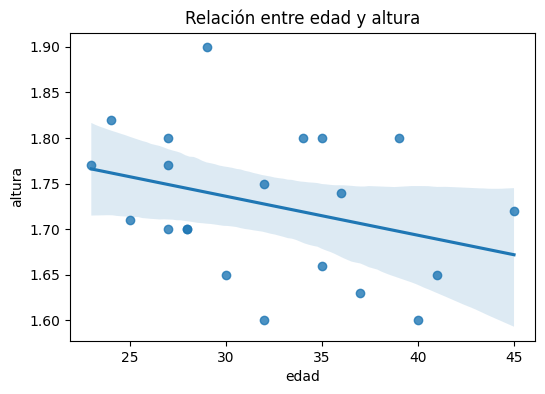

In [17]:
plt.figure(figsize=(6,4))
sns.regplot(data=alumnos, x="edad", y="altura")

plt.title("Relación entre edad y altura")
plt.show()


### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [18]:
alumnos[["edad", "altura"]].corr()

,edad,altura
edad,1.000000,-0.329275
altura,-0.329275,1.000000


No es una buena técnica, correlación muy baja

### Entrena un modelo de regresión lineal

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [20]:
x = alumnos[["edad"]]
y = alumnos["altura"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
modelo = LinearRegression()
modelo.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
print(modelo.intercept_)
print(modelo.coef_)

1.858051298091961
[-0.00435721]


### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [26]:
y_pred = modelo.predict(x_test)

In [27]:
y_pred

array([1.75347826, 1.70990616, 1.71862058, 1.74912105, 1.70119174])

In [28]:
y_test

0     1.82
17    1.80
15    1.75
1     1.71
8     1.74
Name: altura, dtype: float64

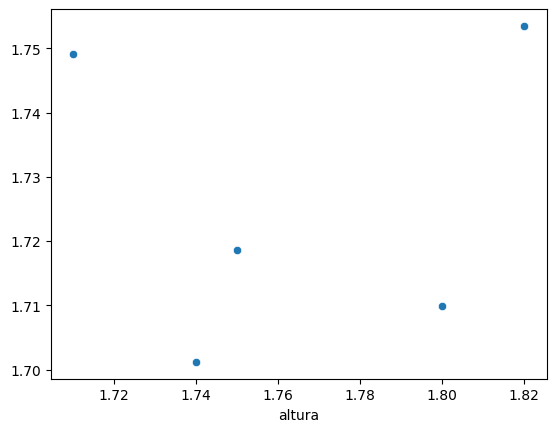

In [35]:
sns.scatterplot(x = y_test, y = y_pred);

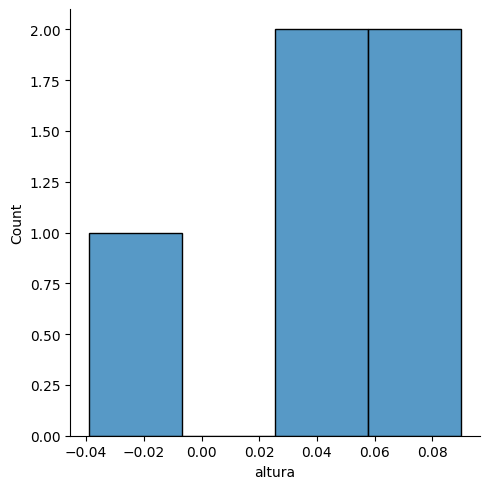

In [30]:
sns.displot((y_test - y_pred));

In [32]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.05318486080700664
MSE: 0.0033126493607306537
RMSE: 0.057555619714591326
